In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect()
con.execute(open('sql/schema.sql').read())

## Vulnerability Ranking
 
Ranks every tract by a composite score weighted across educational disadvantage (40%), poverty rate (30%), and SNAP usage (30%). Education carries the highest weight to reflect its leading position in the random forest analysis.

In [2]:
df_vuln = con.execute(open('sql/queries/01_vulnerability_ranking.sql').read()).df()
df_vuln.head(10)

,tract,poverty_rate,percent_no_hs,snap_rate,OBESITY_CrudePrev,vulnerability_score
0,6.00,63.7,0.000000,19.88,31.9,0.3144
1,18.00,56.7,9.222423,15.95,39.5,0.3023
2,4.00,30.9,28.962331,24.08,41.1,0.2827
3,20.02,38.4,19.296317,14.00,40.7,0.2535
4,19.00,55.3,0.692042,7.09,34.0,0.2445
5,8.00,27.6,16.712080,26.98,38.4,0.2415
6,31.03,21.8,21.618037,29.39,42.4,0.2402
7,20.01,25.8,13.452299,23.69,41.0,0.2146
8,31.04,14.5,27.440253,24.50,41.1,0.2138
9,21.00,27.6,17.034422,16.02,37.7,0.2096


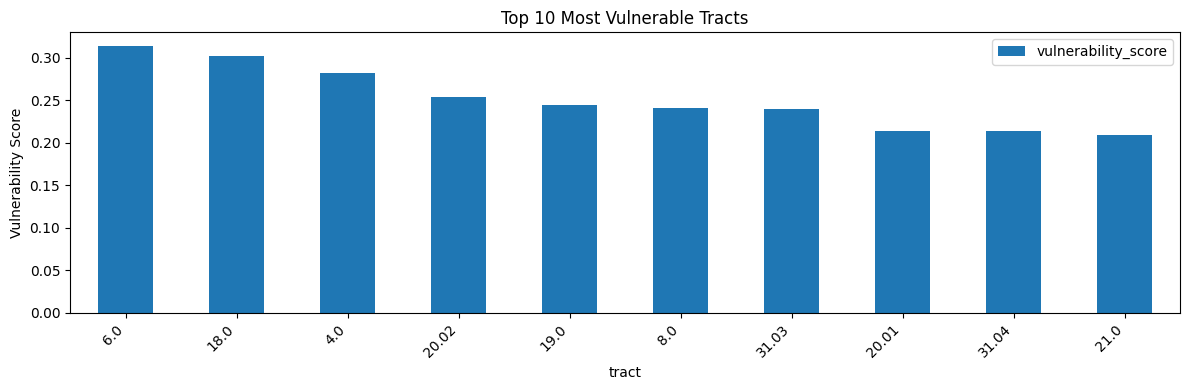

In [3]:
df_vuln.head(10).plot(x='tract', y='vulnerability_score', kind='bar', figsize=(12, 4))
plt.title('Top 10 Most Vulnerable Tracts')
plt.ylabel('Vulnerability Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Finding:** Tract 6.00 ranks first in vulnerability with a poverty rate of 63.7%, one of the highest in the county. Yet its obesity rate is only 31.9% and the ACS records no residents without a high school diploma. This is not a true exception to the education-obesity relationship. Tract 6.00 sits directly on the UNL campus. The poverty here reflects student incomes and graduate stipends rather than structural economic disadvantage. Every student cleared the high school diploma bar to enroll, which explains the 0%. The low obesity reflects the age profile of a student population, not resilience against poverty.

The adjacent tracts 18.00 and 19.00 show why this distinction matters. Both sit just below UNL and also have high poverty (56.7% and 55.3%), but they show obesity rates of 39.5% and 34.0%. These tracts capture the surrounding neighborhoods rather than the student population. The contrast between tract 6.00 and its neighbors illustrates a real limitation of tract level analysis. Poverty means something different depending on who is experiencing it, and the model cannot distinguish student poverty from structural poverty without additional demographic context.

Tract 4.00, ranked third, sits between campus and East Campus and likely contains a mix of student and non-student residents. Its 29.0% without a high school diploma, the highest in the county, signals substantial non-student population, and its 41.1% obesity rate shows that structural disadvantage is present regardless of the student composition.

## Education Outliers

Tracts where percent without a high school diploma exceeds 10% but obesity stays below 35%. Both outliers have geographic explanations that make them less surprising on closer inspection.

In [4]:
df_education = con.execute(open('sql/queries/02_education_outliers.sql').read()).df()
df_education

,tract,percent_no_hs,OBESITY_CrudePrev,snap_rate,poverty_rate,dist_to_grocery_km
0,7.00,16.586248,33.0,16.26,20.8,0.512535
1,10.02,11.075697,33.3,2.80,9.4,0.376623


**Finding:** Tract 7.00 sits directly east of the UNL campus. Its 16.6% without a high school diploma and high SNAP rate (16.3%) suggest real food insecurity, but the student-adjacent population keeps obesity at 33.0%. A younger age profile likely suppresses obesity regardless of economic stress as seen with tract 6. 

Tract 10.02 is primarily commercial, consisting mainly of strips and restaurants. Its small residential population (low poverty at 9.4%, low SNAP at 2.8%) likely reflects a specific demographic living in a commercial corridor rather than a typical neighborhood. Educational disadvantage here does not come with the financial barriers that usually accompany it. 

Both tracts reveal limitations of tract level analysis. Geographic and demographic context changes what the numbers mean, and the dominant education-obesity pattern likely holds better when populations are residentially stable in their neighborhoods.

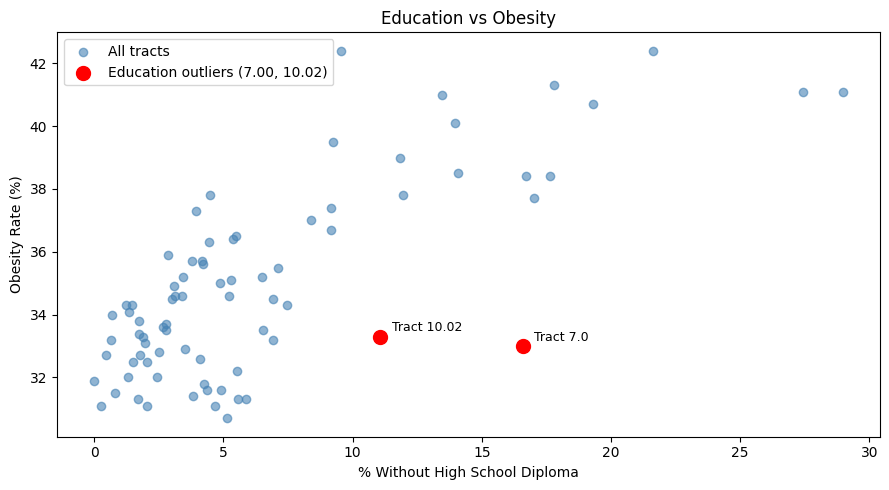

In [14]:
outlier_tracts = df_vuln[df_vuln['tract'].isin([7.00, 10.02])]
main_tracts = df_vuln[~df_vuln['tract'].isin([7.00, 10.02])]
 
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(main_tracts['percent_no_hs'], main_tracts['OBESITY_CrudePrev'],
           alpha=0.6, color='steelblue', label='All tracts')
ax.scatter(outlier_tracts['percent_no_hs'], outlier_tracts['OBESITY_CrudePrev'],
           color='red', zorder=5, s=100, label='Education outliers (7.00, 10.02)')
for _, row in outlier_tracts.iterrows():
    ax.annotate(f"Tract {row['tract']}",
                (row['percent_no_hs'], row['OBESITY_CrudePrev']),
                textcoords="offset points", xytext=(8, 4), fontsize=9)
ax.set_xlabel('% Without High School Diploma')
ax.set_ylabel('Obesity Rate (%)')
ax.set_title('Education vs Obesity')
ax.legend()
plt.tight_layout()
plt.show()

## Food Access vs Health Outcomes

Groups tracts by grocery proximity and compares average obesity, poverty, and SNAP rates across tiers.

In [6]:
df_access = con.execute(open('sql/queries/03_composite_score.sql').read()).df()
df_access

,access_tier,avg_obesity,avg_poverty,avg_snap,tract_count
0,Near grocery,36.42,20.11,12.31,35
1,Far from grocery,33.96,5.30,3.08,5
2,Moderate access,33.71,8.36,5.35,38


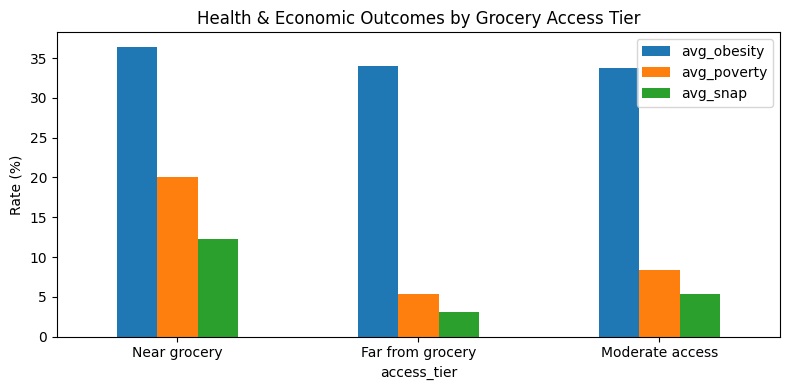

In [7]:
df_access.plot(x='access_tier', y=['avg_obesity', 'avg_poverty', 'avg_snap'], kind='bar', figsize=(8, 4))
plt.title('Health & Economic Outcomes by Grocery Access Tier')
plt.ylabel('Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Finding:** Near grocery tracts average 36.4% obesity, higher than both moderate (33.7%) and far access (34.0%) tracts. This is counterintuitive but consistent with the broader analysis. Urban low-income tracts cluster near stores because cities are dense, but physical proximity does not determine affordability or food quality. The near grocery tier has an average poverty rate of 20.1% and SNAP rate of 12.3%, more than double the other tiers. Structural poverty drives the health outcomes regardless of how close a store is.

## Full Tract Profiles

In [8]:
df_profiles = con.execute(open('sql/queries/04_tract_profiles.sql').read()).df()
df_profiles

,tract,poverty_rate,percent_no_hs,percent_uninsured,percent_no_car,median_income,OBESITY_CrudePrev,DIABETES_CrudePrev,CHD_CrudePrev,dist_to_grocery_km,fast_food_density,snap_rate,pct_under_18,pct_65_plus
0,1.00,12.8,13.973799,6.4,13.838447,48425.0,40.1,12.8,7.6,0.601010,0.093775,11.40,24.85,18.42
1,2.01,16.4,2.857143,5.0,10.810811,55791.0,35.9,11.0,7.0,0.814400,0.216570,4.10,18.71,20.92
2,2.02,23.8,3.939394,5.7,9.119696,45597.0,37.3,9.1,4.9,0.701588,0.000000,18.62,16.50,10.48
3,3.00,19.9,11.961367,13.7,7.757758,55339.0,37.8,10.2,5.5,0.370132,0.342504,16.87,24.71,8.61
4,4.00,30.9,28.962331,16.1,4.530281,47457.0,41.1,11.8,5.7,0.726821,0.230020,24.08,28.18,8.47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,102.03,6.7,4.351204,3.3,6.879607,142083.0,31.6,7.5,4.4,1.567109,0.065606,0.98,27.24,8.03
74,102.04,13.6,6.913891,4.5,1.875293,81212.0,33.2,6.8,3.1,2.598271,0.000000,2.91,27.04,4.55
75,103.00,4.9,1.474654,3.6,2.663578,123875.0,34.3,10.0,5.9,15.309227,0.000000,4.17,22.14,23.96
76,104.01,1.6,1.742919,1.4,2.745098,117669.0,33.4,7.7,4.4,2.308100,0.004867,3.59,32.40,13.35


## Income vs Health Outcomes

Poverty rate and median income both measure economic conditions but capture different things. Poverty is a threshold measure, counting residents below a fixed line. Median income measures the middle of the distribution. Comparing both against obesity shows whether the relationship holds regardless of which economic lens you use.

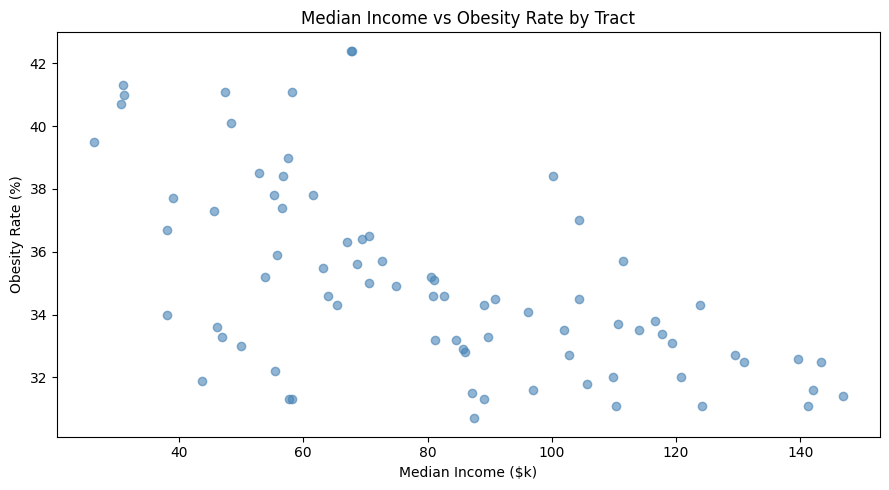

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df_profiles['median_income'] / 1000, df_profiles['OBESITY_CrudePrev'], alpha=0.6, color='steelblue')
ax.set_xlabel('Median Income ($k)')
ax.set_ylabel('Obesity Rate (%)')
ax.set_title('Median Income vs Obesity Rate by Tract')
plt.tight_layout()
plt.show()

**Finding:** Median income shows a clear negative relationship with obesity across tracts. Higher income tracts cluster below 35% obesity while the highest obesity tracts tend to fall below $60k median income. 

The relationship is not perfectly linear. Several low-income tracts have moderate obesity, consistent with the student population effects discussed earlier. The pattern reinforces the poverty rate finding that economic conditions predict health outcomes more reliably than physical food access regardless of how you measure them.

## Poverty Quartile Ranking

Assigns each tract to a poverty quartile using NTILE, then ranks tracts within each quartile by obesity using RANK OVER PARTITION, and computes the average obesity per quartile as a window aggregate.

In [10]:
df_window = con.execute(open('sql/queries/05_poverty_quartile_ranking.sql').read()).df()
df_window.head(20)

,tract,poverty_rate,poverty_quartile,OBESITY_CrudePrev,snap_rate,median_income,obesity_rank_in_quartile,avg_obesity_in_quartile
0,31.03,21.8,1,42.4,29.39,67698.0,1,37.34
1,32.02,19.0,1,42.4,13.71,67886.0,1,37.34
2,17.00,23.8,1,41.3,16.75,31004.0,3,37.34
3,4.00,30.9,1,41.1,24.08,47457.0,4,37.34
4,20.01,25.8,1,41.0,23.69,31080.0,5,37.34
5,20.02,38.4,1,40.7,14.00,30673.0,6,37.34
6,18.00,56.7,1,39.5,15.95,26382.0,7,37.34
7,8.00,27.6,1,38.4,26.98,56775.0,8,37.34
8,3.00,19.9,1,37.8,16.87,55339.0,9,37.34
9,21.00,27.6,1,37.7,16.02,39089.0,10,37.34


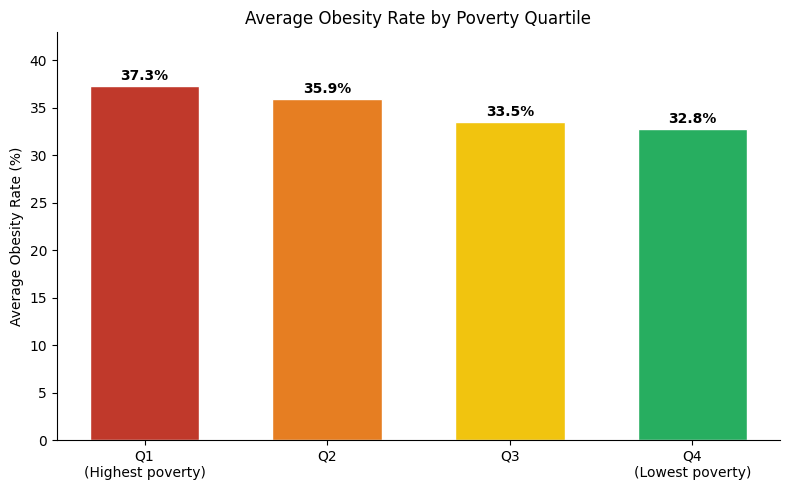

In [11]:
quartile_avg = (
    df_window.drop_duplicates('poverty_quartile')
    .sort_values('poverty_quartile')
    [['poverty_quartile', 'avg_obesity_in_quartile']]
)
labels = ['Q1\n(Highest poverty)', 'Q2', 'Q3', 'Q4\n(Lowest poverty)']
values = quartile_avg['avg_obesity_in_quartile'].tolist()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=['#c0392b', '#e67e22', '#f1c40f', '#27ae60'], edgecolor='white', width=0.6)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, f'{val:.1f}%',
            ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, max(values) * 1.15)
ax.set_ylabel('Average Obesity Rate (%)')
ax.set_title('Average Obesity Rate by Poverty Quartile')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**Finding:** Average obesity declines continually from Q1 (37.3%) to Q4 (32.8%) across poverty quartiles. Tracts 31.03 and 32.02 tie for the highest obesity in Q1 at 42.4%, both combining high SNAP rates with low educational attainment. Tract 6.00 ranks last in Q1 at 31.9%, the clearest outlier, for the reasons discussed above. The decline holds even with that outlier present, which strengthens the conclusion that poverty is a structural driver of health outcomes rather than a red herring due to a few extreme tracts.

## Key Findings

**1. Education and SNAP are the dominant predictors, essentially tied:**
SNAP participation (r = 0.76) and percent without a high school diploma (r = 0.75) are the two strongest bivariate predictors of obesity. The random forest breaks the tie. Education carries an importance weight of 0.527, more than double SNAP at 0.241. Both variables concentrate in the same urban core tracts.

**2. High educational disadvantage with low obesity is rare and geographically explained:**
Only two tracts (7.00 and 10.02) have percent without a high school diploma above 10% and obesity below 35%. Tract 7.00 sits east of UNL where a student-adjacent population suppresses obesity despite real food insecurity. Tract 10.02 is primarily commercial with a small residential population that does not carry the financial barriers typical of educational disadvantage. Both are geographic edge cases rather than true exceptions to the pattern.

**3. Near grocery tracts have the highest average obesity:**
Tracts within 1 km of a grocery store average 36.4% obesity, higher than moderate (33.7%) or far access (34.0%) tracts. Urban low-income tracts cluster near stores, but structural poverty drives food insecurity regardless of physical distance.

**4. Poverty quartile analysis confirms a monotonic gradient:**
Average obesity declines consistently from Q1 (37.3%) to Q4 (32.8%). Poverty is a stronger structural driver of health outcomes than grocery distance alone.